# Human Activity Recognition Using Hidden Markov Models
**Activities:** Still | Standing | Walking | Jumping  
**Sensors:** Accelerometer (ax, ay, az, aT)  
**Implementation:** HMM from scratch (Baum-Welch + Viterbi)

## STEP 1 — Install Dependencies

In [2]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn -q
print('All packages ready')

All packages ready


## STEP 2 — Upload Your CSV Files

### Option B: Google Drive (easier for many files)
Uncomment the Google Drive cell instead.

In [24]:
from google.colab import drive
import shutil, glob
import os

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/HMM_Data'
os.makedirs(DATA_DIR, exist_ok=True)

DRIVE_FOLDER = '/content/drive/MyDrive/HMM_Data'  # change to your folder
for f in glob.glob(os.path.join(DRIVE_FOLDER, '*.csv')):
    shutil.copy(f, DATA_DIR)
    print(f'Copied: {os.path.basename(f)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP 3 — Imports & Configuration

In [25]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURATION  — only change things here
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAMPLING_RATE = 100    # Hz
WINDOW_SIZE   = 100    # samples (= 1 second)
STEP_SIZE     = 50     # 50% overlap
N_STATES      = 4
N_ITER        = 100
CONV_THRESH   = 1e-4
TEST_FILES    = 2      # files per activity held out for testing

# ADD keywords here if your teammate uses different file names
ACTIVITY_KEYWORDS = {
    'Still'   : ['still', 'stationary', 'static', 'rest'],
    'Standing': ['standing', 'stand'],
    'Walking' : ['walking', 'walk'],
    'Jumping' : ['jumping', 'jump'],
}

ACTIVITIES = list(ACTIVITY_KEYWORDS.keys())
STATE_MAP  = {a: i for i, a in enumerate(ACTIVITIES)}
COLORS     = ['#2196F3','#4CAF50','#FF9800','#E91E63']

print('Configuration loaded')
print(f'Window: {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s  |  Step: {STEP_SIZE} samples = {STEP_SIZE/SAMPLING_RATE:.1f}s')

Configuration loaded
Window: 100 samples = 1.0s  |  Step: 50 samples = 0.5s


## STEP 4 — Auto-Detect & Load All CSV Files

The notebook **automatically scans `data/`** and assigns each file to an activity based on its filename.  
**Just upload more files and rerun from this cell** — no other changes needed.

In [26]:
def detect_activity(filename):
    fname_lower = filename.lower()
    for activity, keywords in ACTIVITY_KEYWORDS.items():
        if any(kw in fname_lower for kw in keywords):
            return activity
    return None

def load_and_resample(filepath, target_rate=SAMPLING_RATE):
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]
    rename = {}
    for c in df.columns:
        cl = c.lower()
        if 'time' in cl:                          rename[c] = 'time'
        elif cl.startswith('ax'):                 rename[c] = 'ax'
        elif cl.startswith('ay'):                 rename[c] = 'ay'
        elif cl.startswith('az'):                 rename[c] = 'az'
        elif cl.startswith('at') or 'total' in cl: rename[c] = 'aT'
    df = df.rename(columns=rename)
    available = [c for c in ['time','ax','ay','az','aT'] if c in df.columns]
    df = df[available].dropna()
    if 'aT' not in df.columns:
        df['aT'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    t_uniform = np.arange(df['time'].iloc[0], df['time'].iloc[-1], 1.0/target_rate)
    out = pd.DataFrame({'time': t_uniform})
    for col in ['ax','ay','az','aT']:
        out[col] = np.interp(t_uniform, df['time'].values, df[col].values)
    return out

# Scan and load
all_csvs = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
raw_data = {act: [] for act in ACTIVITIES}
unrecognised = []

for path in all_csvs:
    fname    = os.path.basename(path)
    activity = detect_activity(fname)
    if activity:
        df = load_and_resample(path)
        raw_data[activity].append(df)
        print(f'  [{activity:10s}]  {fname:40s}  {len(df):5d} samples  ({df["time"].max():.1f}s)')
    else:
        unrecognised.append(fname)

print('\nFiles per activity:')
for act in ACTIVITIES:
    dur = sum(df['time'].max() for df in raw_data[act])
    print(f'  {act:10s}: {len(raw_data[act]):2d} files  |  {dur:.1f}s total')

if unrecognised:
    print(f'\nUnrecognised files (add keywords to ACTIVITY_KEYWORDS to include):')
    for f in unrecognised: print(f'  {f}')

  [Jumping   ]  Jumping_2.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_3.csv                              1398 samples  (14.0s)
  [Jumping   ]  Jumping_4.csv                              1398 samples  (14.0s)
  [Jumping   ]  Jumping_5.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_6.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_7.csv                               992 samples  (9.9s)
  [Jumping   ]  Jumping_8.csv                               992 samples  (9.9s)
  [Jumping   ]  Jumping_J5.csv                             1071 samples  (10.8s)
  [Jumping   ]  Jumping_J6.csv                             1069 samples  (10.8s)
  [Jumping   ]  Jumping_Jump1.csv                          1045 samples  (10.5s)
  [Jumping   ]  Jumping_Jump4.csv                          1108 samples  (11.2s)
  [Jumping   ]  Jumping_Jump_3.csv                         1080 samples  (10.9s)
  [Jumping   ]  Jumping_Linear

## STEP 5 — Raw Data Visualisation

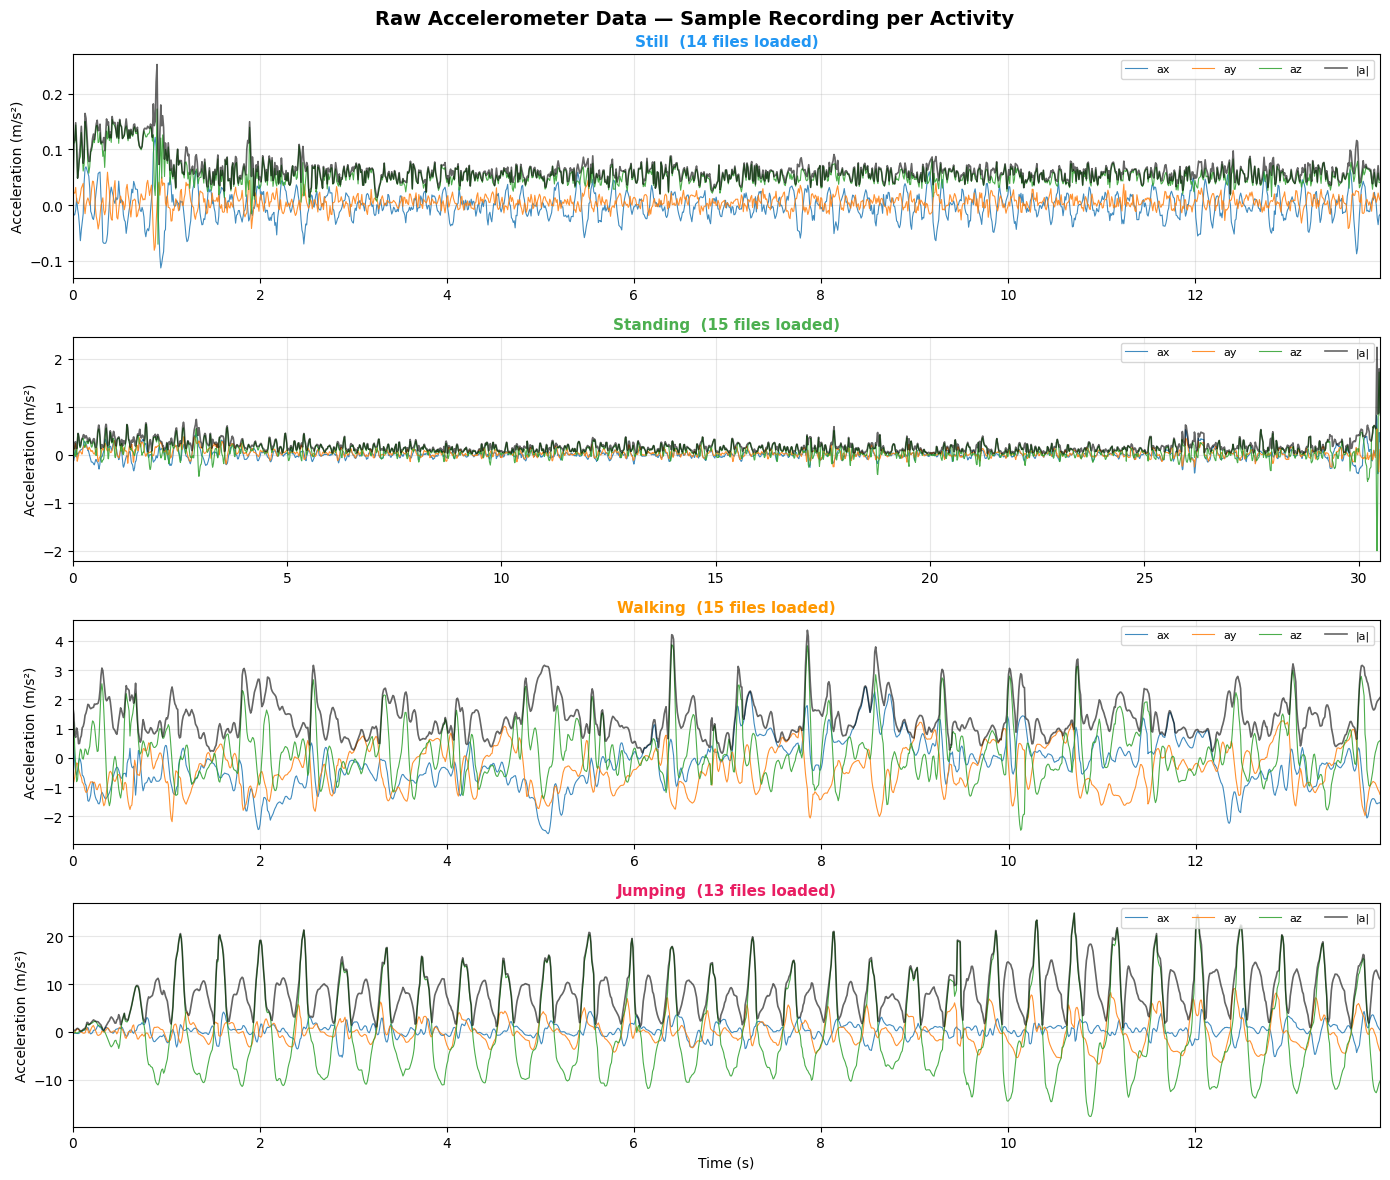

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Raw Accelerometer Data — Sample Recording per Activity', fontsize=14, fontweight='bold')

for ax, activity, color in zip(axes, ACTIVITIES, COLORS):
    if not raw_data[activity]:
        ax.set_title(f'{activity} — NO DATA', color='red'); continue
    df = raw_data[activity][0]
    t  = df['time'] - df['time'].iloc[0]
    ax.plot(t, df['ax'], label='ax', lw=0.8, alpha=0.85)
    ax.plot(t, df['ay'], label='ay', lw=0.8, alpha=0.85)
    ax.plot(t, df['az'], label='az', lw=0.8, alpha=0.85)
    ax.plot(t, df['aT'], label='|a|', color='black', lw=1.2, alpha=0.6)
    ax.set_title(f'{activity}  ({len(raw_data[activity])} files loaded)', fontsize=11, color=color, fontweight='bold')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.grid(alpha=0.3); ax.set_xlim(0, t.max())

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('raw_data_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 6 — Preprocessing (Low-Pass Filter)

In [28]:
def butter_lowpass(data, cutoff=20, fs=SAMPLING_RATE, order=4):
    b, a = signal.butter(order, cutoff/(fs/2), btype='low')
    return signal.filtfilt(b, a, data)

def preprocess(df):
    out = df.copy()
    for col in ['ax','ay','az','aT']: out[col] = butter_lowpass(df[col].values)
    return out

processed_data = {act: [preprocess(df) for df in dfs] for act, dfs in raw_data.items()}
print('Low-pass filter applied (cutoff = 20 Hz)')

Low-pass filter applied (cutoff = 20 Hz)


## STEP 7 — Windowing

**Window = 100 samples = 1 second** at 100 Hz captures ≥1 stride (walking ~1 Hz) and multiple jumps (~2–3 Hz).  
**50% overlap** doubles training samples without leakage.

In [29]:
def sliding_windows(df):
    data, wins = df[['ax','ay','az','aT']].values, []
    for s in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        wins.append(data[s:s+WINDOW_SIZE])
    return wins

windows_by_activity = {}
for activity, dfs in processed_data.items():
    wins = [w for df in dfs for w in sliding_windows(df)]
    windows_by_activity[activity] = wins
    print(f'  {activity:10s}: {len(wins):4d} windows  (from {len(dfs)} files)')

print(f'\nTotal windows: {sum(len(v) for v in windows_by_activity.values())}')

  Still     :  292 windows  (from 14 files)
  Standing  :  364 windows  (from 15 files)
  Walking   :  325 windows  (from 15 files)
  Jumping   :  292 windows  (from 13 files)

Total windows: 1273


## STEP 8 — Feature Extraction

| Domain | Feature | Why it helps distinguish activities |
|---|---|---|
| Time | Mean ax/ay/az/aT | Captures orientation & gravity component |
| Time | Std ax/ay/az/aT | Measures movement intensity |
| Time | RMS ax/ay/az/aT | Overall signal energy (high for jumping) |
| Time | SMA | Signal Magnitude Area — still vs active |
| Time | Axis correlations | Coordinated limb movement |
| Frequency | Dominant frequency | Walking ~2 Hz, Jumping ~3 Hz, Still ~0 Hz |
| Frequency | Spectral energy | High-intensity motion detection |

In [30]:
def extract_features(window):
    ax, ay, az, aT = window[:,0], window[:,1], window[:,2], window[:,3]
    feats = []
    for sig in [ax, ay, az, aT]:
        feats += [np.mean(sig), np.std(sig), np.sqrt(np.mean(sig**2))]
    feats.append(np.mean(np.abs(ax)) + np.mean(np.abs(ay)) + np.mean(np.abs(az)))
    feats += [np.corrcoef(ax,ay)[0,1], np.corrcoef(ax,az)[0,1], np.corrcoef(ay,az)[0,1]]
    for sig in [ax, ay, az, aT]:
        N = len(sig)
        mags = np.abs(fft(sig))[:N//2]
        pos_f = fftfreq(N, d=1.0/SAMPLING_RATE)[:N//2]
        dom = np.argmax(mags[1:]) + 1
        feats += [pos_f[dom], np.sum(mags**2)/N]
    return np.array(feats, dtype=np.float32)

FEATURE_NAMES = (
    [f'{s}_{c}' for c in ['ax','ay','az','aT'] for s in ['mean','std','rms']]
    + ['sma','corr_xy','corr_xz','corr_yz']
    + [f'{f}_{c}' for c in ['ax','ay','az','aT'] for f in ['dom_freq','spec_energy']]
)
print(f'Feature vector length: {len(extract_features(windows_by_activity["Walking"][0]))}')

Feature vector length: 24
